# Portfolio Risk with VaR, Expected Shortfall and GARCH

## Goal

How much can a portfolio lose on a bad day? This project answers that question with
three standard risk measures and then checks whether the answers can be trusted.

- **Value at Risk (VaR)**: the loss that should be exceeded only on 1% of days (99% confidence).
- **Expected Shortfall (ES)**: the average loss on those worst 1% of days. VaR marks where the cliff
  starts, ES measures how deep it is.
- **GARCH**: a volatility model that lets risk change over time (calm periods vs. turbulent ones).

Methods compared: historical simulation, parametric (normal), Monte Carlo, and GARCH-based VaR/ES.
The models are estimated on older data and then **backtested** on newer data: how often did real
losses exceed the predicted VaR?

## Notebook 01: Data

This notebook downloads prices, builds the portfolio and tests whether returns follow a normal
distribution (they do not, which is the main motivation for the rest of the project).

## Portfolio

An equal-weight portfolio (12.5% each) of 8 assets from different asset classes, so that
correlations and crisis behavior differ across holdings.

| Ticker | What it is | Why it is included |
|--------|-----------|--------------------|
| SPY | ETF on the S&P 500 (500 largest US companies) | Benchmark for the US equity market |
| QQQ | ETF on the Nasdaq-100 (large US tech-heavy companies) | Higher volatility than SPY |
| EFA | ETF on developed markets outside the US and Canada (Europe, Japan, Australia) | International diversification |
| EEM | ETF on emerging markets (China, India, Taiwan, Brazil, etc.) | Higher risk, different cycle from the US |
| TLT | ETF on long-term US Treasury bonds (20+ years) | Traditional safe haven, sensitive to interest rates |
| GLD | ETF backed by physical gold | Behaves independently of corporate earnings |
| AAPL | Apple Inc. (single stock) | Idiosyncratic risk of one company |
| JPM | JPMorgan Chase (largest US bank) | Financial sector exposure |

## Data

- Source: Yahoo Finance via `yfinance`, daily prices from 2012 to today.
- Prices are adjusted for dividends and splits (`auto_adjust=True`).
- The sample covers several stress periods: the COVID crash (March 2020) and the 2022 stock-bond sell-off.

## Caveats

- AAPL is a large holding inside SPY and QQQ, so the portfolio has some overlapping exposure.
- AAPL and JPM were picked with hindsight (both performed well). This does not affect a risk
  analysis, but the portfolio's historical returns should not be read as a forecast.

In [4]:
import yfinance as yf
import matplotlib.pyplot as plt
import os

[*********************100%***********************]  7 of 8 completed


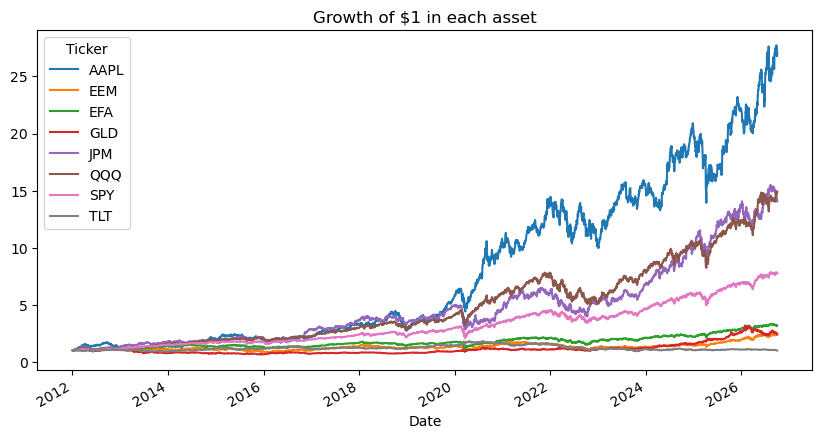

In [3]:
tickers = ["SPY", "QQQ", "EFA", "EEM", "TLT", "GLD", "AAPL", "JPM"]
px = yf.download(tickers, start="2012-01-01", auto_adjust=True)["Close"].dropna()

px.to_csv("../data/prices.csv")   # saving data to the folder
(px / px.iloc[0]).plot(figsize=(10, 5), title="Growth of $1 in each asset")
plt.show()

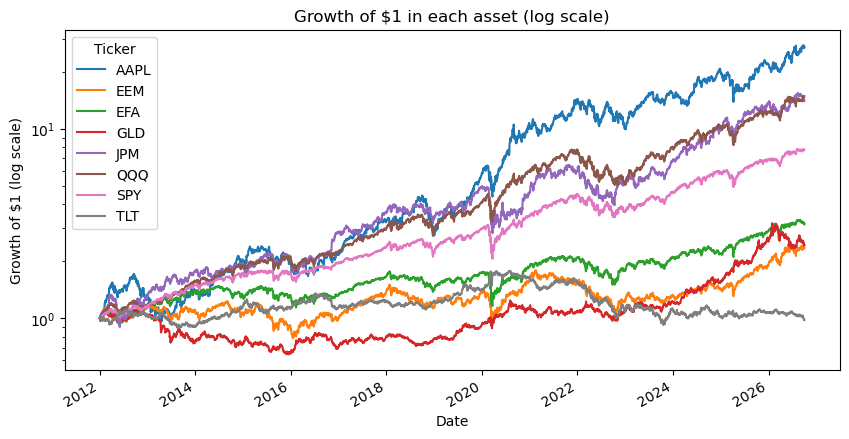

In [6]:
os.makedirs("../figures", exist_ok=True)

ax = (px / px.iloc[0]).plot(figsize=(10, 5), logy=True,
                            title="Growth of $1 in each asset (log scale)")
ax.set_ylabel("Growth of $1 (log scale)")

# savefig must come BEFORE plt.show(), otherwise the saved image is blank
plt.savefig("../figures/01_growth_of_1usd.png", dpi=200, bbox_inches="tight")
plt.show()

## Observations

- Over 2012-2026 the assets diverged strongly: AAPL grew roughly 27x, QQQ and JPM about 15x,
  SPY about 8x, while TLT (long-term Treasuries) was nearly flat.
- Almost all assets fell together in March 2020, so diversification offered little protection
  during the COVID crash.
- In 2022 stocks and long-term bonds (TLT) declined at the same time, a sign that the
  stock-bond hedge is not stable and depends on the interest-rate regime.
- Single-name stocks (AAPL, JPM) show deeper drawdowns than diversified ETFs,
  e.g. AAPL in early 2025.
- Note: AAPL is also a large holding inside SPY and QQQ, so the portfolio has some overlapping exposure.
- Note: AAPL and JPM were chosen with hindsight, so this chart says nothing about future returns.
  We use it only to study risk.